In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# CSV
path = '/content/2023 QS World University Rankings.csv'
data = pd.read_csv(path, encoding='latin1')
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1422 entries, 0 to 1421
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   ï»¿Rank        1422 non-null   int64  
 1   institution    1422 non-null   object 
 2   location code  1422 non-null   object 
 3   location       1422 non-null   object 
 4   ar score       1422 non-null   float64
 5   ar rank        1422 non-null   object 
 6   er score       1421 non-null   float64
 7   er rank        1422 non-null   object 
 8   fsr score      1420 non-null   float64
 9   fsr rank       1422 non-null   object 
 10  cpf score      1417 non-null   float64
 11  cpf rank       1422 non-null   object 
 12  ifr score      1324 non-null   float64
 13  ifr rank       1324 non-null   object 
 14  isr score      1365 non-null   float64
 15  isr rank       1365 non-null   object 
 16  irn score      1409 non-null   float64
 17  irn rank       1409 non-null   object 
 18  ger scor

In [5]:
print(data.describe())

           ï»¿Rank     ar score     er score    fsr score    cpf score  \
count  1422.000000  1422.000000  1421.000000  1420.000000  1417.000000   
mean    711.500000    20.124684    20.657143    29.997113    24.529358   
std     410.640354    22.802706    24.027928    28.172207    27.910952   
min       1.000000     1.000000     1.000000     1.000000     1.000000   
25%     356.250000     5.400000     4.400000     8.200000     3.100000   
50%     711.500000    10.800000    10.300000    18.250000    11.100000   
75%    1066.750000    23.775000    27.000000    43.500000    39.400000   
max    1422.000000   100.000000   100.000000   100.000000   100.000000   

         ifr score    isr score    irn score    ger score  score scaled  
count  1324.000000  1365.000000  1409.000000  1410.000000    500.000000  
mean     31.659517    26.545348    49.570121    26.186809     44.619400  
std      34.170817    30.896854    30.205439    26.201036     18.655057  
min       1.000000     1.000000     1

In [4]:
data = data.rename(columns={'ï»¿Rank': 'rank','old_col_2': 'new_name_2'})
data.head()

,rank,institution,location code,location,ar score,ar rank,er score,er rank,fsr score,fsr rank,...,cpf rank,ifr score,ifr rank,isr score,isr rank,irn score,irn rank,ger score,ger rank,score scaled
0,1,Massachusetts Institute of Technology (MIT),US,United States,100.0,5,100.0,4,100.0,14,...,5,100.0,54,90.0,109,96.1,58,100.0,3,100.0
1,2,University of Cambridge,UK,United Kingdom,100.0,2,100.0,2,100.0,11,...,55,100.0,60,96.3,70,99.5,6,100.0,9,98.8
2,3,Stanford University,US,United States,100.0,4,100.0,5,100.0,6,...,9,99.8,74,60.3,235,96.3,55,100.0,2,98.5
3,4,University of Oxford,UK,United Kingdom,100.0,3,100.0,3,100.0,8,...,64,98.8,101,98.4,54,99.9,3,100.0,7,98.4
4,5,Harvard University,US,United States,100.0,1,100.0,1,99.4,35,...,2,76.9,228,66.9,212,100.0,1,100.0,1,97.6


In [6]:
data.isnull().sum()

,0
ï»¿Rank,0
institution,0
location code,0
location,0
ar score,0
ar rank,0
er score,1
er rank,0
fsr score,2
fsr rank,0


In [12]:
import pandas as pd

# Load the data if it's not already loaded
path = '/content/2023 QS World University Rankings.csv'
data = pd.read_csv(path, encoding='latin1')

# Rename the rank column if it hasn't been already
data = data.rename(columns={'ï»¿Rank': 'rank'})

# Create the universities_by_country DataFrame
universities_by_country = data.groupby('location').size().reset_index(name='count')
universities_by_country['percentage'] = (universities_by_country['count'] / universities_by_country['count'].sum()) * 100
universities_by_country = universities_by_country.sort_values(by='percentage', ascending=False)

display(universities_by_country.head())

,location,count,percentage
96,United States,201,14.135021
95,United Kingdom,90,6.329114
16,China (Mainland),71,4.992968
45,Japan,50,3.516174
74,Russia,48,3.375527


In [7]:
unique_values={col:data[col].unique() for col in data.columns }
for col, values in unique_values.items():
  print(f"Columna: {col}")
  print(f"numero de valores unicos: {len(values)}")
  print(f"valores unicos: {values[:10]}")
  print("--"*50)

Columna: ï»¿Rank
numero de valores unicos: 1422
valores unicos: [ 1  2  3  4  5  6  7  8  9 10]
----------------------------------------------------------------------------------------------------
Columna: institution
numero de valores unicos: 1422
valores unicos: ['Massachusetts Institute of Technology (MIT) ' 'University of Cambridge'
 'Stanford University' 'University of Oxford' 'Harvard University'
 'California Institute of Technology (Caltech)' 'Imperial College London'
 'UCL' 'ETH Zurich - Swiss Federal Institute of Technology'
 'University of Chicago']
----------------------------------------------------------------------------------------------------
Columna: location code
numero de valores unicos: 100
valores unicos: ['US' 'UK' 'CH' 'SG' 'CN' 'HK' 'JP' 'FR' 'KR' 'AU']
----------------------------------------------------------------------------------------------------
Columna: location
numero de valores unicos: 100
valores unicos: ['United States' 'United Kingdom' 'Switzerland'

In [10]:
universities_by_country = data.groupby('location').size().reset_index(name='count')
universities_by_country['percentage'] = (universities_by_country['count'] / universities_by_country['count'].sum()) * 100
universities_by_country = universities_by_country.sort_values(by='percentage', ascending=False)

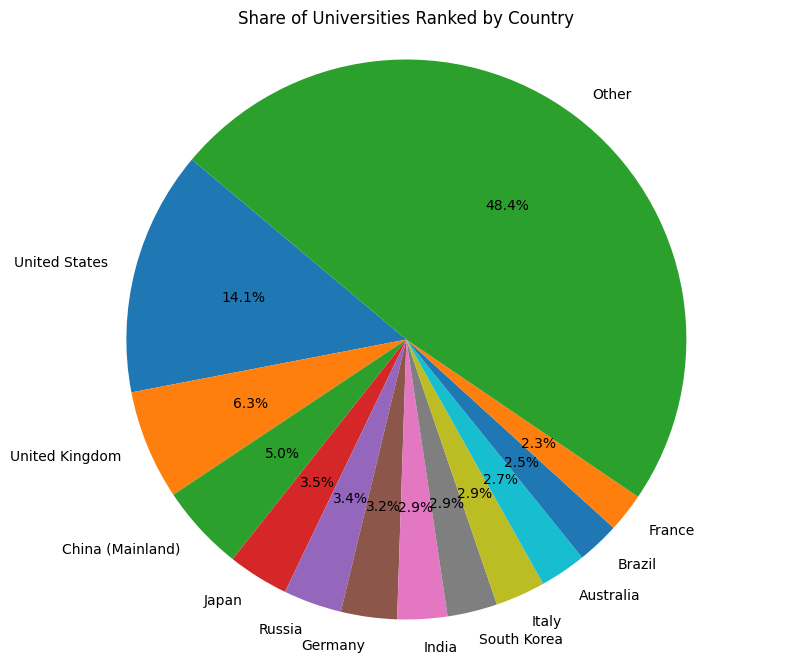

In [14]:
top_n = 12
other_percentage = universities_by_country['percentage'][top_n:].sum()

pie_data = universities_by_country.head(top_n).copy()
pie_data.loc['Other'] = {'location': 'Other', 'count': universities_by_country['count'][top_n:].sum(), 'percentage': other_percentage}
pie_data.reset_index(drop=True, inplace=True)

plt.figure(figsize=(10, 8))
plt.pie(pie_data['percentage'], labels=pie_data['location'], autopct='%1.1f%%', startangle=140)
plt.title('Share of Universities Ranked by Country')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

In [13]:
import pandas as pd

# Load the data if it's not already loaded
path = '/content/2023 QS World University Rankings.csv'
data = pd.read_csv(path, encoding='latin1')

# Rename the rank column if it hasn't been already
data = data.rename(columns={'ï»¿Rank': 'rank'})

# Create the universities_by_country DataFrame
universities_by_country = data.groupby('location').size().reset_index(name='count')
universities_by_country['percentage'] = (universities_by_country['count'] / universities_by_country['count'].sum()) * 100
universities_by_country = universities_by_country.sort_values(by='percentage', ascending=False)

display(universities_by_country.head())

,location,count,percentage
96,United States,201,14.135021
95,United Kingdom,90,6.329114
16,China (Mainland),71,4.992968
45,Japan,50,3.516174
74,Russia,48,3.375527


In [11]:
display(universities_by_country.head())

,location,count,percentage
96,United States,201,14.135021
95,United Kingdom,90,6.329114
16,China (Mainland),71,4.992968
45,Japan,50,3.516174
74,Russia,48,3.375527


In [11]:
universities_by_country.head()

,location,count,percentage
96,United States,201,14.135021
95,United Kingdom,90,6.329114
16,China (Mainland),71,4.992968
45,Japan,50,3.516174
74,Russia,48,3.375527
